<a href="https://colab.research.google.com/github/ashleygittens1-netizen/Ashley/blob/main/MY_STOCKS_WITH_5_DAY_WINDOW_Portfolio_Optimization_RealStocks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Integer AND Nonlinear Optimization: Portfolio Allocation
## Real Stock Market Data — Apparel, Entertainment & Beauty (March–April 2026)

A portfolio is a collection of assets. In a stock portfolio, the investor chooses the stocks, and the dollar value of each, to hold in the portfolio at the start of an investment period. Over this period, the values of the stocks may change. At the end of the period, performance can be measured by the total value of the portfolio.

The performance of individual stocks can be measured in two ways: **return** and **risk**.
- **Return** = the percentage growth in the value of the stock (higher is better)
- **Risk** = the variability (standard deviation) of those returns (lower is safer)

**Goal:** Find the optimal allocation of your money across these 20 stocks to maximize return for a given level of risk.

---
### Our 20 Stocks (3 Sectors)

| Sector | Tickers |
|---|---|
| 👗 Apparel | NKE, LULU, GAP, AEO, URBN, RL, PVH, VFC |
| 🎬 Entertainment | DIS, NFLX, WBD, PARA, LYV, IMAX |
| 💄 Beauty | ULTA, ELF, EL, COTY, KVUE, VSCO |

---
### Integer Constraints (Yes/No Rules)
- Must include at least 1 Beauty stock (ULTA or ELF)
- Must select **no more than 5 stocks** total
- **Contingency:** If you buy NFLX, you must also buy DIS
- **Mutually Exclusive:** Can't hold both NKE and LULU (direct competitors)
- **Floor:** Any selected stock must be at least 10% of portfolio
- **Cap:** No single stock can exceed 50% of portfolio

In [ ]:
%%capture
import sys
import os

# Install required solvers (only runs on Google Colab)
if 'google.colab' in sys.modules:
    !pip install idaes-pse --pre
    !idaes get-extensions --to ./bin
    os.environ['PATH'] += ':bin'

In [ ]:
# Install all required packages
!pip install pyomo yfinance -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

from pyomo.environ import *
from pyomo.opt import SolverStatus, TerminationCondition

print("✅ All packages loaded successfully!")

✅ All packages loaded successfully!


# Step 1: Load Real Market Data

We use **Yahoo Finance** (`yfinance`) to pull real daily closing prices for all 20 stocks from March 1, 2026 through today. We then convert prices into **daily percentage returns** — this is the same type of data the original notebook used, just at a daily (rather than monthly) frequency.

In [ ]:
# ─────────────────────────────────────────────────────────────────
# DATA LOADING: Real Market Data — March & April 2026
# Sectors: Apparel, Entertainment, Beauty
# ─────────────────────────────────────────────────────────────────

# 20 Stocks across 3 sectors
TICKERS = [
    # 👗 Apparel (8)
    'NKE',  'LULU', 'GAP',  'AEO',
    'URBN', 'RL',   'PVH',  'VFC',
    # 🎬 Entertainment (6)
    'DIS',  'NFLX', 'WBD',  'PARA',
    'LYV',  'IMAX',
    # 💄 Beauty (6)
    'ULTA', 'ELF',  'EL',   'COTY',
    'KVUE', 'VSCO'
]

# Pull March 1 → April 14, 2026 (all of March + April so far)
print("Downloading data from Yahoo Finance...")
raw = yf.download(TICKERS, start='2026-03-01', end='2026-04-14', progress=False)['Close']

# Drop any tickers that returned no data
raw = raw.dropna(axis=1, how='all')

# Convert closing prices → daily percentage returns
# This is: (today's price - yesterday's price) / yesterday's price
df_all = raw.pct_change().dropna()

print(f"\n✅ Tickers loaded:  {list(df_all.columns)}")
print(f"   Trading days:    {len(df_all)}")
print(f"   Date range:      {df_all.index[0].date()} → {df_all.index[-1].date()}")
df_all.tail()

ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: PARA"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['PARA']: YFTzMissingError('possibly delisted; no timezone found')



✅ Tickers loaded:  ['AEO', 'COTY', 'DIS', 'EL', 'ELF', 'GAP', 'IMAX', 'KVUE', 'LULU', 'LYV', 'NFLX', 'NKE', 'PVH', 'RL', 'ULTA', 'URBN', 'VFC', 'VSCO', 'WBD']
   Trading days:    29
   Date range:      2026-03-03 → 2026-04-13


Ticker,AEO,COTY,DIS,EL,ELF,GAP,IMAX,KVUE,LULU,LYV,NFLX,NKE,PVH,RL,ULTA,URBN,VFC,VSCO,WBD
Date,,,,,,,,,,,,,,,,,,,
2026-04-07,-0.006865,-0.023148,-0.005193,-0.024538,-0.032901,-0.024458,-0.013476,-0.032948,-0.016071,-0.011429,-0.001112,-0.030434,0.022269,-0.025266,-0.019202,-0.026905,-0.006448,0.006631,-0.001459
2026-04-08,0.054723,-0.009479,0.035498,0.032818,0.010304,0.035634,-0.015464,0.036461,0.033774,0.033293,0.005768,0.010307,0.058937,0.074014,0.001109,0.053754,0.054867,0.061342,0.006576
2026-04-09,0.012562,0.000000,0.006150,0.025896,0.034968,0.036571,-0.009162,0.005190,0.048156,0.000611,0.026763,0.020172,0.041029,0.025946,-0.000056,0.007329,0.027405,-0.000388,-0.000726
2026-04-10,-0.005159,0.038278,-0.006213,-0.008460,0.018770,-0.002276,-0.000264,-0.004590,-0.015915,-0.018758,0.009407,-0.031364,-0.003842,-0.013683,-0.023292,-0.001746,-0.007621,-0.022701,-0.003269
2026-04-13,-0.013100,0.041475,0.020268,0.025870,0.007523,-0.038783,-0.023784,-0.005187,-0.007934,0.031945,0.001456,0.006804,-0.019065,-0.007608,0.012260,-0.017201,0.011520,-0.008537,-0.001822


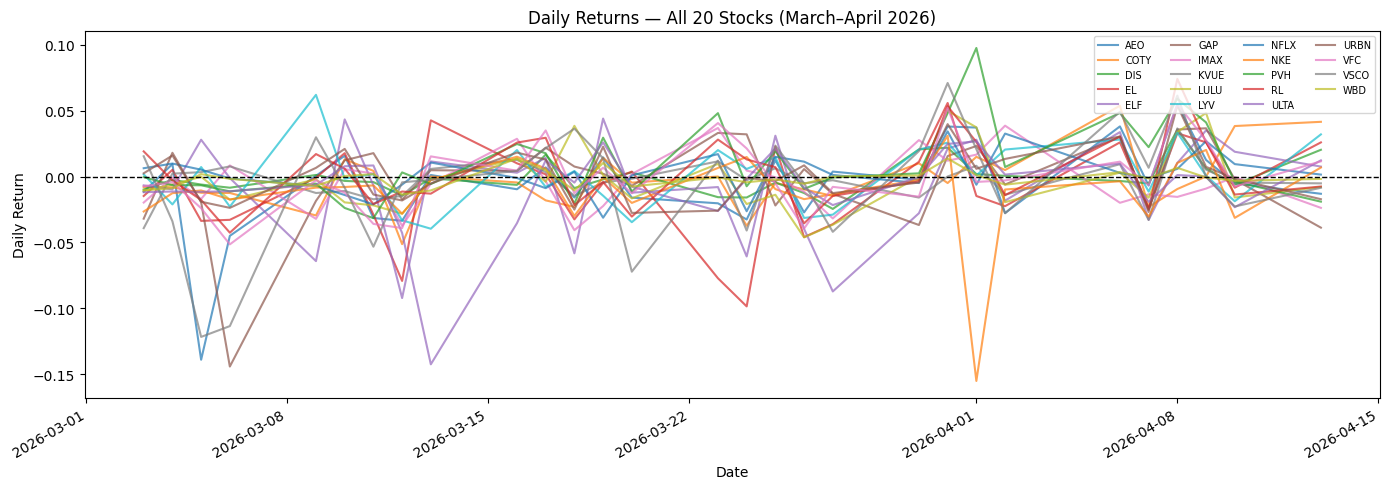

In [ ]:
# Plot all daily returns — see the volatility!
df_all.plot(figsize=(14, 5), alpha=0.7)
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.title('Daily Returns — All 20 Stocks (March–April 2026)')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.legend(loc='upper right', ncol=4, fontsize=7)
plt.tight_layout()
plt.show()

# Step 2: The 5-Day Rolling Window

Since we are **buying and selling every day**, we don't want to look at all 30+ days of history equally. Instead, we use a **5-day rolling window** — only the last 5 trading days are used to calculate our mean return and covariance.

**Why 5 days?**
- It makes the optimizer **react to recent market behavior**
- If a stock had a bad week, the model sees that immediately
- Each time you run this notebook, `df_all.tail(5)` automatically grabs the freshest 5 days

```
Today:     [Day1, Day2, Day3, Day4, Day5]  ← optimizer uses THESE
Tomorrow:  [Day2, Day3, Day4, Day5, Day6]  ← window slides forward
```

In [ ]:
# ─────────────────────────────────────────────────────────────────
# 5-DAY ROLLING WINDOW
# Uses only the most recent 5 trading days for optimization
# ─────────────────────────────────────────────────────────────────
WINDOW = 5
df = df_all.tail(WINDOW)
tickers = df.columns.tolist()  # dynamic — works even if a ticker gets dropped

# These two are the INPUTS to the Pyomo model
df_return = df.mean()   # average daily return for each stock over last 5 days
df_cov    = df.cov()    # how stocks move together (covariance matrix)

print(f"📅 Window: {df.index[0].date()} → {df.index[-1].date()} ({WINDOW} trading days)")
print(f"\n📈 Average Daily Return (last 5 days):")
print(df_return.round(5).to_string())
print(f"\n📊 Covariance Matrix:")
print(df_cov.round(7))

📅 Window: 2026-04-07 → 2026-04-13 (5 trading days)

📈 Average Daily Return (last 5 days):
Ticker
AEO     0.00843
COTY    0.00943
DIS     0.01010
EL      0.01032
ELF     0.00773
GAP     0.00134
IMAX   -0.01243
KVUE   -0.00021
LULU    0.00840
LYV     0.00713
NFLX    0.00846
NKE    -0.00490
PVH     0.01987
RL      0.01068
ULTA   -0.00584
URBN    0.00305
VFC     0.01594
VSCO    0.00727
WBD    -0.00014

📊 Covariance Matrix:
Ticker       AEO      COTY       DIS        EL       ELF       GAP      IMAX  \
Ticker                                                                         
AEO     0.000761 -0.000374  0.000349  0.000390  0.000177  0.000760 -0.000008   
COTY   -0.000374  0.000842 -0.000022  0.000130  0.000333 -0.000383  0.000012   
DIS     0.000349 -0.000022  0.000316  0.000377  0.000099  0.000194 -0.000097   
EL      0.000390  0.000130  0.000377  0.000640  0.000422  0.000416 -0.000097   
ELF     0.000177  0.000333  0.000099  0.000422  0.000630  0.000516  0.000065   
GAP     0.000760 

Stock Summary (sorted by return, highest first):
        Avg_Daily_Return  Std_Dev_Return
Ticker                                  
PVH              0.01987         0.03185
VFC              0.01594         0.02609
RL               0.01068         0.04020
EL               0.01032         0.02529
DIS              0.01010         0.01778
COTY             0.00943         0.02901
NFLX             0.00846         0.01100
AEO              0.00843         0.02758
LULU             0.00840         0.03034
ELF              0.00773         0.02511
VSCO             0.00727         0.03214
LYV              0.00713         0.02428
URBN             0.00305         0.03130
GAP              0.00134         0.03430
WBD             -0.00014         0.00387
KVUE            -0.00021         0.02495
NKE             -0.00490         0.02423
ULTA            -0.00584         0.01494
IMAX            -0.01243         0.00863


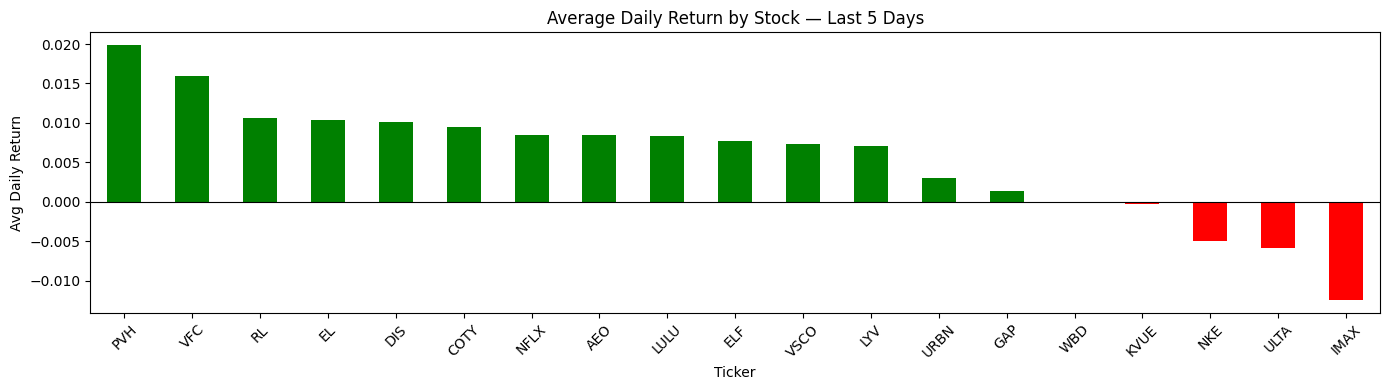

In [ ]:
# Summary stats for the 5-day window
Avg_Return = pd.DataFrame(df_return, columns=['Avg_Daily_Return'])
Std_Dev    = pd.DataFrame(df.std(),  columns=['Std_Dev_Return'])
summary    = pd.concat([Avg_Return, Std_Dev], axis=1).sort_values('Avg_Daily_Return', ascending=False)
print("Stock Summary (sorted by return, highest first):")
print(summary.round(5).to_string())

# Color-coded bar chart
colors = ['green' if x >= 0 else 'red' for x in summary['Avg_Daily_Return']]
summary['Avg_Daily_Return'].plot(kind='bar', color=colors, figsize=(14, 4))
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Average Daily Return by Stock — Last 5 Days')
plt.ylabel('Avg Daily Return')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 3: Covariance and Modern Portfolio Theory

**Covariance** tells us how two stocks move together:
- **Positive covariance** → they tend to go up and down together (bad for diversification)
- **Negative covariance** → when one goes up, the other tends to go down (great for diversification!)

The goal of MPT is to combine stocks that *don't* move together, so the portfolio as a whole is smoother than any individual stock.

In [ ]:
# Covariance matrix (used in the risk calculation)
Covariance_matrix = df.cov()
print('Covariance Matrix (5-Day Window):')
print(Covariance_matrix.round(7))

Covariance Matrix (5-Day Window):
Ticker       AEO      COTY       DIS        EL       ELF       GAP      IMAX  \
Ticker                                                                         
AEO     0.000761 -0.000374  0.000349  0.000390  0.000177  0.000760 -0.000008   
COTY   -0.000374  0.000842 -0.000022  0.000130  0.000333 -0.000383  0.000012   
DIS     0.000349 -0.000022  0.000316  0.000377  0.000099  0.000194 -0.000097   
EL      0.000390  0.000130  0.000377  0.000640  0.000422  0.000416 -0.000097   
ELF     0.000177  0.000333  0.000099  0.000422  0.000630  0.000516  0.000065   
GAP     0.000760 -0.000383  0.000194  0.000416  0.000516  0.001176  0.000112   
IMAX   -0.000008  0.000012 -0.000097 -0.000097  0.000065  0.000112  0.000074   
KVUE    0.000597  0.000009  0.000358  0.000514  0.000381  0.000627 -0.000014   
LULU    0.000599 -0.000321  0.000273  0.000561  0.000469  0.000911 -0.000008   
LYV     0.000321  0.000055  0.000412  0.000501  0.000088  0.000061 -0.000170   
NFLX  

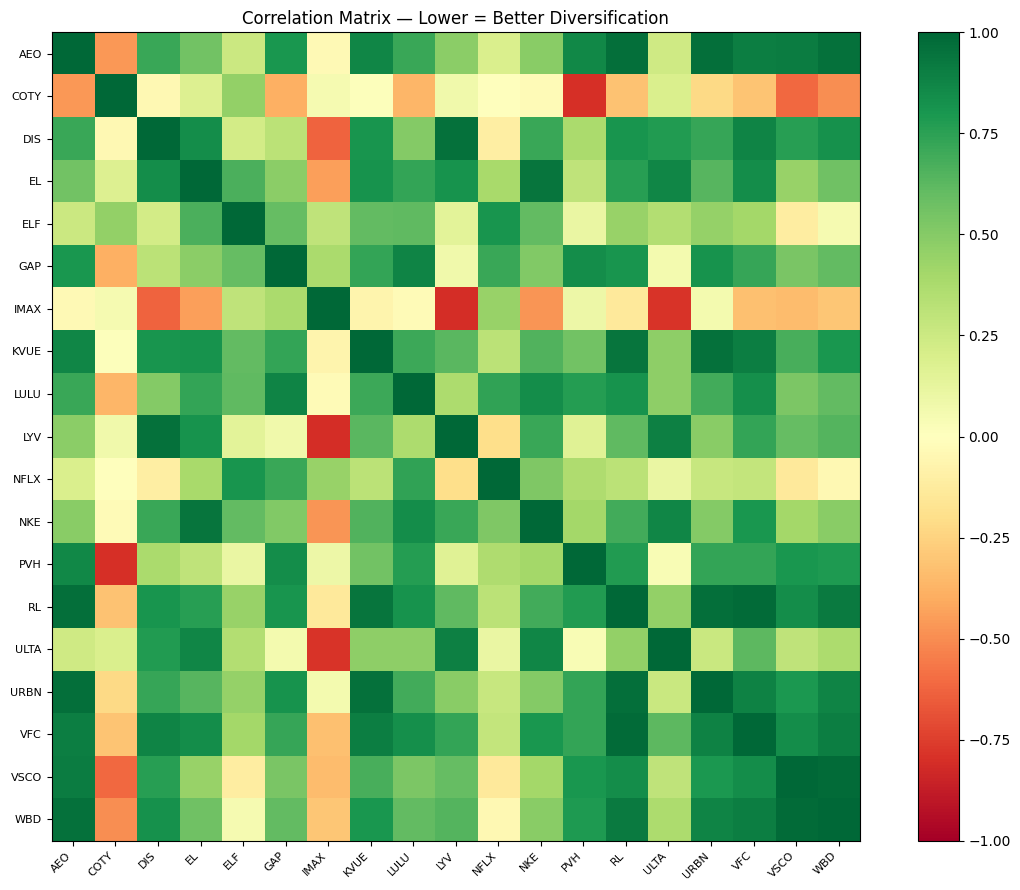


Green = negative correlation (good for diversification)
Red   = positive correlation (they move together)


In [ ]:
# Correlation matrix (easier to read — ranges from -1 to +1)
import matplotlib.colors as mcolors

Corr_matrix = df.corr()

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(Corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im)
ax.set_xticks(range(len(tickers)))
ax.set_yticks(range(len(tickers)))
ax.set_xticklabels(tickers, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(tickers, fontsize=8)
plt.title('Correlation Matrix — Lower = Better Diversification')
plt.tight_layout()
plt.show()

print("\nGreen = negative correlation (good for diversification)")
print("Red   = positive correlation (they move together)")

# Step 4: Build the Integer Optimization Model

Now we build the Pyomo model. This is the heart of the project.

### Decision Variables
- `x[t]` — what **proportion** (0 to 1) of money to put in stock `t`
- `y[t]` — **binary** (0 or 1): do we even include stock `t` in the portfolio?

### Constraints
1. All proportions must sum to 1 (invest 100% of money)
2. No stock can exceed 50% of portfolio (cap)
3. If selected, stock must be at least 10% (floor)
4. Must pick at most 5 stocks
5. Must include at least 1 Beauty stock (ULTA or ELF)
6. If you buy NFLX, you must also buy DIS (contingency)
7. Can't hold both NKE and LULU (mutually exclusive)

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CORE MODEL FUNCTION
# Takes a risk limit, returns optimal allocations + expected return
# ─────────────────────────────────────────────────────────────────

def solve_portfolio(r_limit):
    m = ConcreteModel()

    # ── Decision Variables ────────────────────────────────────────
    # x[t] = proportion of portfolio in stock t (continuous, 0 to 1)
    m.x = Var(tickers, domain=NonNegativeReals, bounds=(0, 1))
    # y[t] = binary: 1 if we buy stock t, 0 if not
    m.y = Var(tickers, domain=Binary)

    # ── Objective: Maximize Expected Return ───────────────────────
    m.obj = Objective(
        expr=sum(m.x[t] * df_return[t] for t in tickers),
        sense=maximize
    )

    # ── Basic Constraint: Must invest 100% ────────────────────────
    m.sum_w = Constraint(expr=sum(m.x[t] for t in tickers) == 1)

    # ── Linking Constraints: Connect x and y ─────────────────────
    # If y[t]=0 (don't buy), then x[t] must be 0
    # If y[t]=1 (buy), then x[t] is between 0.10 and 0.50
    m.cap   = Constraint(tickers, rule=lambda m, t: m.x[t] <= 0.50 * m.y[t])  # Max 50% cap
    m.floor = Constraint(tickers, rule=lambda m, t: m.x[t] >= 0.10 * m.y[t])  # Min 10% floor

    # ── Integer / Logic Constraints ───────────────────────────────
    # 1. Must include at least 1 Beauty stock
    m.beauty = Constraint(expr=m.y['ULTA'] + m.y['ELF'] + m.y['EL'] + m.y['COTY'] + m.y['KVUE'] >= 1)

    # 2. At most 5 stocks selected
    m.max_stocks = Constraint(expr=sum(m.y[t] for t in tickers) <= 5)

    # 3. Contingency: If NFLX is selected, DIS must also be selected
    #    (m.y['DIS'] - m.y['NFLX'] >= 0  means: DIS >= NFLX)
    m.contingency = Constraint(expr=m.y['DIS'] - m.y['NFLX'] >= 0)

    # 4. Mutually Exclusive: Can't hold both NKE and LULU
    m.exclusive = Constraint(expr=m.y['NKE'] + m.y['LULU'] <= 1)

    # ── Risk Constraint (Quadratic) ───────────────────────────────
    # Risk = sum of x[i] * Cov(i,j) * x[j] for all pairs
    # This is the portfolio variance — must stay below r_limit
    risk_expr = sum(
        m.x[t1] * df_cov.at[t1, t2] * m.x[t2]
        for t1 in tickers for t2 in tickers
    )
    m.risk_limit = Constraint(expr=risk_expr <= r_limit)

    # ── Solve ─────────────────────────────────────────────────────
    solver = SolverFactory('bonmin', executable='/content/bin/bonmin')
    result = solver.solve(m, tee=False)

    if result.solver.termination_condition == TerminationCondition.optimal:
        alloc = {t: value(m.x[t]) for t in tickers}
        ret   = value(m.obj)
        return alloc, ret
    return None, None

print("✅ Model function defined. Ready to run.")

✅ Model function defined. Ready to run.


# Step 5: Run the Optimization Loop

We run the model across many different risk levels, from very low to very high. At each risk level, the solver finds the best possible portfolio. This gives us the **Efficient Frontier** — the curve that shows the best return for every possible risk tolerance.

In [ ]:
# ─────────────────────────────────────────────────────────────────
# OPTIMIZATION LOOP: Scan risk levels, record best portfolio each time
# Daily returns are small, so risk levels are scaled down vs monthly data
# ─────────────────────────────────────────────────────────────────

risk_limits = np.arange(0.00005, 0.002, 0.00005)  # Daily scale (much smaller than monthly)
results     = []

print(f"Scanning {len(risk_limits)} risk levels...\n")

for i, r in enumerate(risk_limits):
    alloc, ret = solve_portfolio(r)
    if alloc is not None:
        row = alloc.copy()
        row['Risk']   = r
        row['Return'] = ret
        results.append(row)
        if (i + 1) % 5 == 0:
            print(f"  Risk level {i+1}/{len(risk_limits)} done... Return = {ret:.5f}")
    else:
        print(f"  Risk {r:.5f}: Infeasible (constraints too tight at this risk level)")

print(f"\n✅ Solved {len(results)} feasible portfolios out of {len(risk_limits)} risk levels.")

Scanning 39 risk levels...

  Risk level 5/39 done... Return = 0.01607
  Risk level 10/39 done... Return = 0.01717
  Risk level 15/39 done... Return = 0.01734
  Risk level 20/39 done... Return = 0.01734
  Risk level 25/39 done... Return = 0.01734
  Risk level 30/39 done... Return = 0.01734
  Risk level 35/39 done... Return = 0.01734

✅ Solved 39 feasible portfolios out of 39 risk levels.


# Step 6: Results & Parameter Analysis

In [ ]:
# Build results dataframe
res_df = pd.DataFrame(results).set_index('Risk')
print("Portfolio Allocations at Each Risk Level:")
res_df.round(3)

Portfolio Allocations at Each Risk Level:


,AEO,COTY,DIS,EL,ELF,GAP,IMAX,KVUE,LULU,LYV,NFLX,NKE,PVH,RL,ULTA,URBN,VFC,VSCO,WBD,Return
Risk,,,,,,,,,,,,,,,,,,,,
0.00005,0.0,0.354,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.312,0.0,0.0,0.0,0.000,0.0,0.334,0.009
0.00010,0.0,0.500,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500,0.0,0.0,0.0,0.000,0.0,0.000,0.015
0.00015,0.0,0.389,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500,0.0,0.0,0.0,0.111,0.0,0.000,0.015
0.00020,0.0,0.329,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500,0.0,0.0,0.0,0.171,0.0,0.000,0.016
0.00025,0.0,0.281,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500,0.0,0.0,0.0,0.219,0.0,0.000,0.016
0.00030,0.0,0.240,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500,0.0,0.0,0.0,0.260,0.0,0.000,0.016
0.00035,0.0,0.204,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500,0.0,0.0,0.0,0.296,0.0,0.000,0.017
0.00040,0.0,0.171,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500,0.0,0.0,0.0,0.329,0.0,0.000,0.017
0.00045,0.0,0.141,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500,0.0,0.0,0.0,0.359,0.0,0.000,0.017


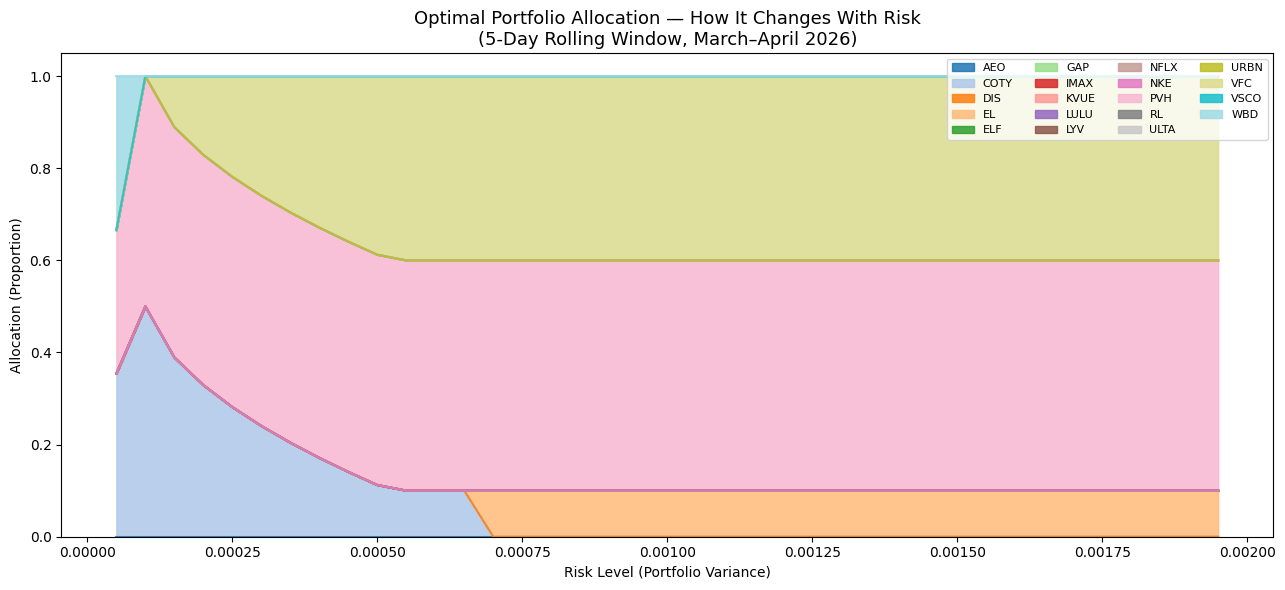

LEFT side  = low risk → more diversified (spread across many stocks)
RIGHT side = high risk → concentrated (dumps money into best-returning stock)


In [ ]:
# ── Plot 1: Stacked Area Chart — How allocation shifts with risk ──
res_df[tickers].plot(kind='area', stacked=True, figsize=(13, 6), alpha=0.85, colormap='tab20')
plt.title('Optimal Portfolio Allocation — How It Changes With Risk\n(5-Day Rolling Window, March–April 2026)', fontsize=13)
plt.xlabel('Risk Level (Portfolio Variance)')
plt.ylabel('Allocation (Proportion)')
plt.legend(loc='upper right', ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

print("LEFT side  = low risk → more diversified (spread across many stocks)")
print("RIGHT side = high risk → concentrated (dumps money into best-returning stock)")

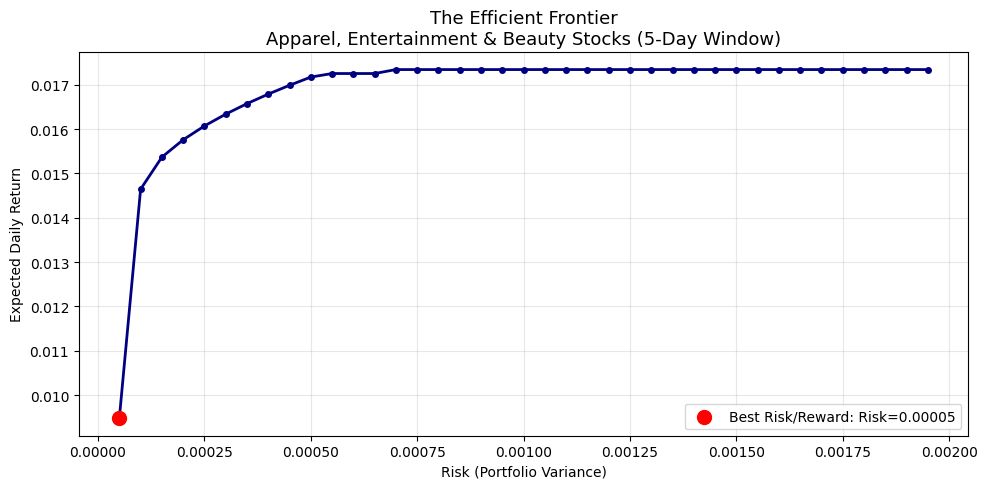


🔴 Optimal Risk/Reward point: Risk = 0.00005, Return = 0.00948
Any point on this curve is an optimal portfolio. You choose based on your risk tolerance.


In [ ]:
# ── Plot 2: The Efficient Frontier ────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(res_df.index, res_df['Return'], 'o-', color='navy', markersize=4, linewidth=2)
plt.title('The Efficient Frontier\nApparel, Entertainment & Beauty Stocks (5-Day Window)', fontsize=13)
plt.xlabel('Risk (Portfolio Variance)')
plt.ylabel('Expected Daily Return')
plt.grid(True, alpha=0.3)

# Mark the "knee" — best risk/reward tradeoff
best_idx = (res_df['Return'] / res_df.index).idxmax()
plt.scatter([best_idx], [res_df.loc[best_idx, 'Return']],
            color='red', s=100, zorder=5, label=f'Best Risk/Reward: Risk={best_idx:.5f}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n🔴 Optimal Risk/Reward point: Risk = {best_idx:.5f}, Return = {res_df.loc[best_idx, 'Return']:.5f}")
print("Any point on this curve is an optimal portfolio. You choose based on your risk tolerance.")

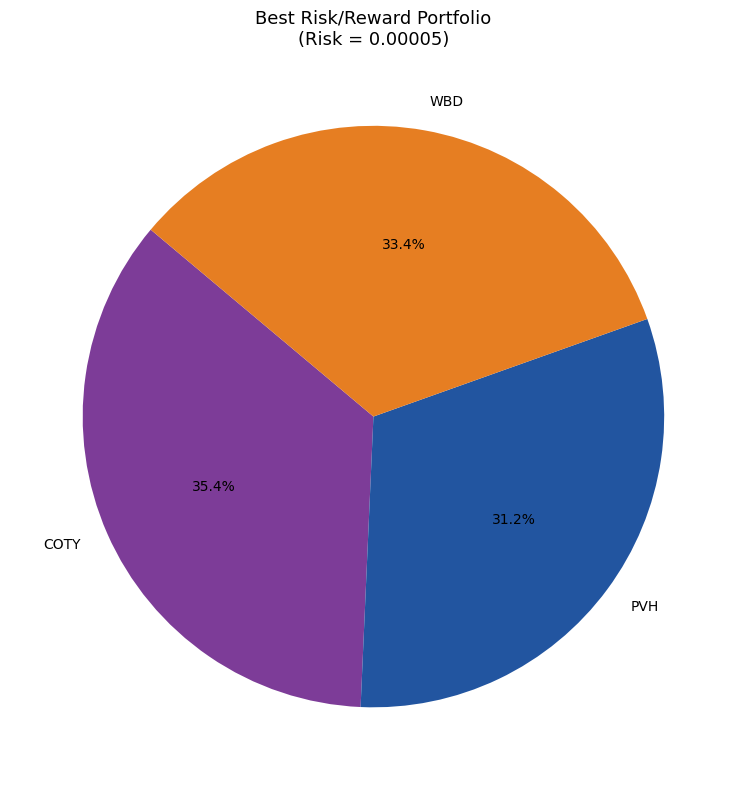


Allocation breakdown:
  COTY    35.4%
  WBD     33.4%
  PVH     31.2%


In [ ]:
# ── Plot 3: Best Portfolio Pie Chart ──────────────────────────────
best_alloc = res_df.loc[best_idx, tickers]
active = best_alloc[best_alloc > 0.001]  # only show stocks with real allocation

# Color by sector
sector_colors = {
    'NKE':'#4a90d9','LULU':'#5ba3e8','GAP':'#2c6fad','AEO':'#1a4f80',
    'URBN':'#6ab4f5','RL':'#3d7db5','PVH':'#2255a0','VFC':'#7ec8f7',
    'DIS':'#e8a020','NFLX':'#c0392b','WBD':'#e67e22','PARA':'#d35400',
    'LYV':'#f39c12','IMAX':'#e74c3c',
    'ULTA':'#9b59b6','ELF':'#8e44ad','EL':'#a569bd',
    'COTY':'#7d3c98','KVUE':'#c39bd3','VSCO':'#d2b4de'
}
pie_colors = [sector_colors.get(t, '#aaaaaa') for t in active.index]

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    active.values,
    labels=active.index,
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=140
)
for t in autotexts:
    t.set_fontsize(10)
ax.set_title(f'Best Risk/Reward Portfolio\n(Risk = {best_idx:.5f})', fontsize=13)
plt.tight_layout()
plt.show()

print("\nAllocation breakdown:")
for t, w in active.sort_values(ascending=False).items():
    print(f"  {t:6s}  {w*100:.1f}%")

# Step 7: Constraint Validation

Let's verify that all our integer constraints were respected across every risk level.

In [ ]:
# ─────────────────────────────────────────────────────────────────
# VALIDATION SUITE: Check all constraints held across all results
# ─────────────────────────────────────────────────────────────────
epsilon    = 1e-5
is_invested = res_df[tickers] > epsilon

# 1. Floor violations (invested but < 10%)
floor_v = ((res_df[tickers] > epsilon) & (res_df[tickers] < 0.0999)).sum().sum()

# 2. Cap violations (> 50%)
cap_v = (res_df[tickers] > 0.5001).sum().sum()

# 3. Max 5 stocks
count_v = (is_invested.sum(axis=1) > 5).sum()

# 4. Mutual exclusion: NKE + LULU <= 1
exclusive_v = ((is_invested['NKE'].astype(int) + is_invested['LULU'].astype(int)) > 1).sum()

# 5. Contingency: If NFLX then DIS
contingency_v = (is_invested['NFLX'] & ~is_invested['DIS']).sum()

# 6. Beauty requirement
beauty_cols   = [t for t in ['ULTA','ELF','EL','COTY','KVUE'] if t in tickers]
beauty_v      = (is_invested[beauty_cols].sum(axis=1) < 1).sum()

# 7. Portfolio sum
avg_sum = res_df[tickers].sum(axis=1).mean()

# Active weight range
active_w = res_df[tickers].values[res_df[tickers].values > epsilon]

print("═" * 45)
print("   PORTFOLIO CONSTRAINT VALIDATION REPORT")
print("═" * 45)
print(f"  Risk levels solved:         {len(res_df)}")
print(f"  Floor violations (< 10%):   {floor_v}  {'✅' if floor_v==0 else '❌'}")
print(f"  Cap violations (> 50%):     {cap_v}  {'✅' if cap_v==0 else '❌'}")
print(f"  Max-5 stock violations:     {count_v}  {'✅' if count_v==0 else '❌'}")
print(f"  NKE+LULU violations:        {exclusive_v}  {'✅' if exclusive_v==0 else '❌'}")
print(f"  NFLX→DIS violations:        {contingency_v}  {'✅' if contingency_v==0 else '❌'}")
print(f"  Beauty stock violations:    {beauty_v}  {'✅' if beauty_v==0 else '❌'}")
print(f"  Avg portfolio sum:          {avg_sum:.4f}  {'✅' if abs(avg_sum-1)<0.01 else '❌'}")
if len(active_w) > 0:
    print(f"  Active weight range:        {active_w.min():.3f} → {active_w.max():.3f}")
print("═" * 45)

═════════════════════════════════════════════
   PORTFOLIO CONSTRAINT VALIDATION REPORT
═════════════════════════════════════════════
  Risk levels solved:         39
  Floor violations (< 10%):   0  ✅
  Cap violations (> 50%):     0  ✅
  Max-5 stock violations:     0  ✅
  NKE+LULU violations:        0  ✅
  NFLX→DIS violations:        0  ✅
  Beauty stock violations:    0  ✅
  Avg portfolio sum:          1.0000  ✅
  Active weight range:        0.100 → 0.500
═════════════════════════════════════════════


# Summary

✅ **What this notebook does:**
- Pulls **real daily stock data** for 20 US stocks (Apparel, Entertainment, Beauty) for March–April 2026
- Uses a **5-day rolling window** so allocations reflect the most recent market behavior
- Runs **Integer + Nonlinear Optimization** (Bonmin solver via Pyomo) to find the optimal portfolio at each risk level
- Enforces real business rules (caps, floors, sector requirements, contingency, mutual exclusion)
- Outputs the **Efficient Frontier** and **best risk/reward allocation**

**To rerun for tomorrow:** Simply run all cells again. The `yf.download()` call will fetch updated prices automatically, and `df_all.tail(5)` will use the newest 5 trading days.